# **Flower Classification Competition (30%)**
For this competition, we will use the Flower Recognition. This dataset contains 4317 images of flowers. The data collection is based on the data from flickr, google images, yandex images. The aim is to recognize flower species from a photo.  

The pictures are divided into five classes: chamomile, tulip, rose, sunflower, dandelion. For each class there are about 800 photos. Photos are not high resolution, about 320x240 pixels. Note that for this dataset the photos are not all at a fixed size, they have different proportions.

We provide baseline code that includes the following features:

*   Loading and Analysing the Flowers dataset using torchvision.
*   Providing some augmentations (on loading)
*   Defining a simple convolutional neural network.
*   How to use existing loss function for the model learning.
*   Train the network on the training data.
*   Test the trained network on the testing data.
*   Generate prediction for the random test image(s).

The following improvements could be considered:
-------
1. Change of advanced training parameters: Learning Rate, Optimizer, Batch-size, Number of Max Epochs, and Drop-out.
2. Use of a new loss function.
3. Additional/better data augmentation
4. Architectural Changes: Batch Normalization, Residual layers, Attention Block, and other variants.

Your code should be modified from the provided baseline. A pdf report of a maximum of two pages is required to explain the changes you made from the baseline, why you chose those changes, and the improvements they achieved.

Marking Rules:
-------
We will mark the competition based on the final test accuracy on testing images and your report.

Final mark (out of 50) = acc_mark + efficiency mark + report mark
###Acc_mark 10:

We will rank all the submission results based on their test accuracy. Zero improvement over the baseline yields 0 marks. Maximum improvement over the baseline will yield 10 marks. There will be a sliding scale applied in between.

###Efficiency mark 10:

Efficiency considers not only the accuracy, but the computational cost of running the model (flops: https://en.wikipedia.org/wiki/FLOPS). Efficiency for our purposes is defined to be the ratio of accuracy (in %) to Gflops. Please report the computational cost for your final model and include the efficiency calculation in your report. Maximum improvement over the baseline will yield 10 marks. Zero improvement over the baseline yields zero marks, with a sliding scale in between.

###Report mark 30:
Your report should comprise:
1. An introduction showing your understanding of the task and of the baseline model: [10 marks]

2. A description of how you have modified aspects of the system to improve performance. [10 marks]

A recommended way to present a summary of this is via an "ablation study" table, eg:

|Method1|Method2|Method3|Accuracy|
|---|---|---|---|
|N|N|N|60%|
|Y|N|N|65%|
|Y|Y|N|77%|
|Y|Y|Y|82%|

3. Explanation of the methods for reducing the computational cost and/or improve the trade-off between accuracy and cost: [5 marks]

4. Limitations/Conclusions: [5 marks]

In [33]:
##################################################################################################################################
### Subject: Computer Vision
### Year: 2025
### Student Name: Darcy Stephens, Yaman Ashqar
### Student ID: a1887089, a1884774
### Comptetion Name: Flowers Classification Competition
### Final Results:
### ACC:         GFLOPs:
##################################################################################################################################

In [34]:
# Importing libraries.

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

# To avoid non-essential warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid
from sklearn.model_selection import train_test_split

In [35]:
print("CUDA available:", torch.cuda.is_available())
print("GPU device count:", torch.cuda.device_count())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")
# if torch.cuda.is_available():
#     device = torch.device("cuda")  # Use GPU
#     print("CUDA is available. Using GPU.")
# else:
device = torch.device("cpu")   # Fall back to CPU
print("CUDA not available. Using CPU.")

CUDA available: True
GPU device count: 1
GPU name: NVIDIA GeForce RTX 3060 Ti
CUDA not available. Using CPU.


In [36]:
# Performing Image Transformations.

train_transform=transforms.Compose([
        transforms.Resize(224),             # resize shortest side to 224 pixels
        transforms.CenterCrop(224),         # crop longest side to 224 pixels at center
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
])

In [37]:
# Mounting G-Drive to get your dataset.
# To access Google Colab GPU; Go To: Edit >>> Network Settings >>> Hardware Accelarator: Select GPU.
# Reference: https://towardsdatascience.com/google-colab-import-and-export-datasets-eccf801e2971
# from google.colab import drive
# drive.mount('/content/drive')

# Dataset path. Ensure that the file path correspond to the path you have here. It is expected that you unzip the data folders before running the notebook.
darcy_dd = '/home/yaman/CompVis/flower/flowers'
yaman_dd = '/home/yaman/CompVis/flower/flowers'
dataset=datasets.ImageFolder(root=darcy_dd,transform=train_transform)
dataset

Dataset ImageFolder
    Number of datapoints: 4317
    Root location: /home/yaman/CompVis/flower/flowers
    StandardTransform
Transform: Compose(
               Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [38]:
# Google drive sanity check, can be ignored
# from google.colab import drive
# drive.mount('/content/drive')
# !ls "/content/drive/MyDrive/Datasets"

In [39]:
# Checking the flower class types.
class_names=dataset.classes
print(class_names)
print(len(class_names))

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
5


In [40]:
# Train and Test data split.
train_indices, test_indices = train_test_split(list(range(len(dataset.targets))), test_size=0.2, stratify=dataset.targets)
train_data = torch.utils.data.Subset(dataset, train_indices)
test_data = torch.utils.data.Subset(dataset, test_indices)

In [41]:
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [42]:
#increase batch size to 32 - larger batch size means less batches, reducing training time
train_loader=DataLoader(train_data,batch_size=32,shuffle=True)
test_loader=DataLoader(test_data,batch_size=32)

In [43]:
print(len(train_data))
print(len(test_data))

3453
864


In [44]:
# Preview of the datasets.
for images, labels in train_loader:
    break
#print the labels
print('Label:', labels.numpy())
print('Class:', *np.array([class_names[i] for i in labels]))

im=make_grid(images,nrow=5)

Label: [4 3 4 1 2 1 3 1 1 0 0 0 0 4 0 0 2 0 4 1 2 0 1 3 1 3 0 0 4 0 4 1]
Class: tulip sunflower tulip dandelion rose dandelion sunflower dandelion dandelion daisy daisy daisy daisy tulip daisy daisy rose daisy tulip dandelion rose daisy dandelion sunflower dandelion sunflower daisy daisy tulip daisy tulip dandelion


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


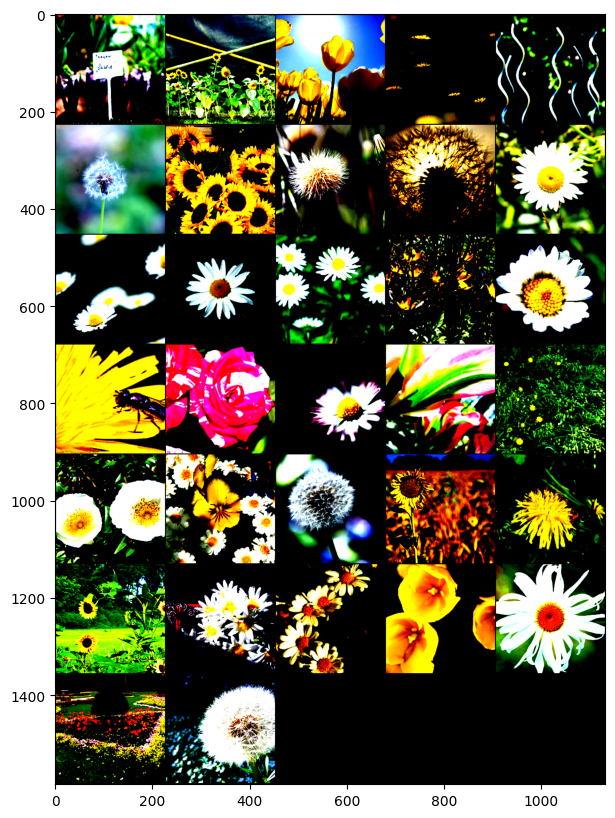

In [45]:
plt.figure(figsize=(10,10))
plt.imshow(np.transpose(im.numpy(),(1,2,0)))

In [46]:
# Inverse Normalization.
inv_normalize=transforms.Normalize(mean=[-0.485/0.229,-0.456/0.224,-0.406/0.225],
                                     std=[1/0.229,1/0.224,1/0.225])
im=inv_normalize(im)

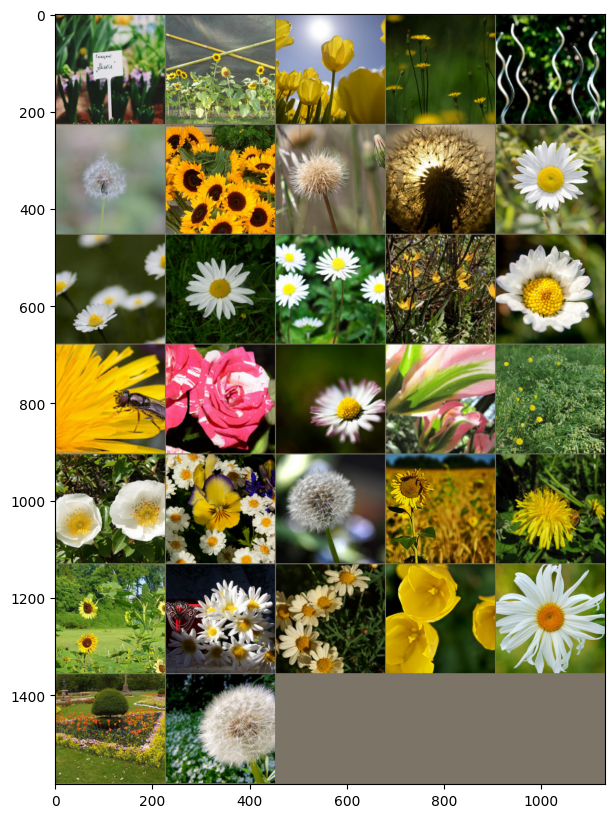

In [47]:
plt.figure(figsize=(10,10))
plt.imshow(np.transpose(im.numpy(),(1,2,0)))

# Model Architecture Improvement

In [48]:
# Convolutional Network - Baseline
#DJ notes - could do transfer learning, ResNet is one of the best ones for object classification
#since we have to show we tried a few things, i reckon we take the approach of:
#deepen and widen model -show results (it will be bad)
#add in batch normalisation  - show results (it will be slightly better)
#use transfer learning with resnet
class Baseline(nn.Module):
  def __init__(self, classes):
    super().__init__()
    self.num_classes=classes
     #DJ notes - super shallow network, flowers have very fine feautres, we should deepen this.
    self.conv1=nn.Conv2d(3,6,3,1)
    self.conv2=nn.Conv2d(6,16,3,1)
    self.conv3=nn.Conv2d(16,32,3,1)
     #DJ notes - Add in batch normalization to improve generalisation and convergence, will increase efficiency
    self.fc1=nn.Linear(32*26*26,120)
    self.fc2=nn.Linear(120,84)
    self.fc3=nn.Linear(84,20)
    self.fc4=nn.Linear(20,self.num_classes)
  def forward(self,X):
    X=F.relu(self.conv1(X))
    X=F.max_pool2d(X,2,2)
    X=F.relu(self.conv2(X))
    X=F.max_pool2d(X,2,2)
    X=F.relu(self.conv3(X))
    #pooling is downsampling the feature maps - reducing the computational complexity and enhancing translation invariance
    X=F.max_pool2d(X,2,2)
    X=X.view(-1,32*26*26)
      #DJ notes - could implement PReLU, extension of leakyReLU that is good for large image datasets, can introduce risk of overfitting tho
    X=F.relu(self.fc1(X))
    X=F.relu(self.fc2(X))
    X=F.relu(self.fc3(X))
    X=self.fc4(X)
    return F.log_softmax(X, dim=1)

In [ ]:
# #intentionally cruddy, deeper but narrow
# class Deep_baseline(nn.Module):
#     def __init__(self, classes):
#         super().__init__()
#         self.num_classes = classes
#                             #number of channles, number of outputs
#         self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)

#         self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)

#         self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
    
#         self.conv4 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        
#         self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

#         self.fc1 = nn.Linear(512, 256)
#         self.fc2 = nn.Linear(256, 128)
#         self.fc3 = nn.Linear(128, 128)
#         self.fc4 = nn.Linear(128, self.num_classes)


#     def forward(self, x):
#         x = F.relu(self.conv1(x))
#         x = F.relu(self.conv2(x))
#         x = F.relu(self.conv3(x))
#         x = F.relu(self.conv4(x))


#         x = self.global_pool(x)
#         x = torch.flatten(x, 1)


#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         x = F.relu(self.fc3(x))
#         x = self.fc4(x)
#         return F.log_softmax(x, dim=1)


In [ ]:
# #created a deeper and narrower model, changed the batch size to 32, used batch normalisation
# #accuracy at 76%
# #uses BN, maxpooling for decreasing computation cost
# class Deep_baseline_V2(nn.Module):
#     def __init__(self, classes):
#         super().__init__()
#         self.num_classes = classes
#                             #number of channles, number of outputs
#         self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
#         self.bn1 = nn.BatchNorm2d(64)

#         self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
#         self.bn2 = nn.BatchNorm2d(128)

#         self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
#         self.bn3 = nn.BatchNorm2d(256)

#         self.conv4 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
#         self.bn4 = nn.BatchNorm2d(512)


#         self.pool = nn.MaxPool2d(2, 2)
#         self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

#         self.fc1 = nn.Linear(512, 256)
#         self.fc2 = nn.Linear(256, 128)
#         self.fc3 = nn.Linear(128, 128)
#         self.fc4 = nn.Linear(128, self.num_classes)


#     def forward(self, x):
#         x = self.pool(F.relu(self.bn1(self.conv1(x))))
#         x = self.pool(F.relu(self.bn2(self.conv2(x))))
#         x = self.pool(F.relu(self.bn3(self.conv3(x))))
#         x = self.pool(F.relu(self.bn4(self.conv4(x))))


#         x = self.global_pool(x)
#         x = torch.flatten(x, 1)


#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         x = F.relu(self.fc2(x))
#         x = self.fc3(x)
#         return F.log_softmax(x, dim=1)


In [51]:

#uses BN, maxpooling for decreasing computation cost and drop outlayers - best model will be trained with a LR optimizer
class Deep_baseline_V3(nn.Module):
    def __init__(self, classes):
        super().__init__()
        self.num_classes = classes
                            #number of channles, number of outputs
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(512)


        self.pool = nn.MaxPool2d(2, 2)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, self.num_classes)


    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = F.dropout(x, p=0.2, training=self.training)


        x = self.global_pool(x)
        x = torch.flatten(x, 1)


        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)


In [52]:
#uses BN, maxpooling for decreasing computation cost and drop outlayers, has been made deeper- best model will be trained with a LR optimizer
class Deep_baseline_V4(nn.Module):
    def __init__(self, classes):
        super().__init__()
        self.num_classes = classes

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(512)

        self.conv5 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(512)

        self.conv6 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(2, 2)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, self.num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.pool(F.relu(self.bn5(self.conv5(x))))
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.pool(F.relu(self.bn6(self.conv6(x))))
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return F.log_softmax(x, dim=1)


In [ ]:
num_classes = 5
                    #CHANGE THE MODEL NAME
CNNmodel=to_device(Deep_baseline(num_classes),device)
train_loader = DeviceDataLoader(train_loader, device)
test_loader = DeviceDataLoader(test_loader, device)
criterion=nn.CrossEntropyLoss()

#DJ notes - look to modify the lr, find optimal lr

In [ ]:
CNNmodel

Deep_baseline(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=5, bias=True)
)

In [ ]:
import time
start_time = time.time()

results = {}
lr_schedule = [0.001, 0.0001, 0.00001]
# Issues with testing Deep_baseline, Deep_baseline_V2, commented those models out
models = [Baseline,  Deep_baseline_V3, Deep_baseline_V4]
epochs = 20

for model in models:
    model_name = model.__name__
    print(f"\nTraining model: {model_name}")

    # Initialize result containers for this model
    train_losses = {}
    test_losses = {}
    train_correct = {}
    test_correct = {}

    for lr in lr_schedule:
        print(f"  Learning rate: {lr}")
        CNNmodel = model(num_classes).to(device)
        optimizer = torch.optim.Adam(CNNmodel.parameters(), lr=lr)

        train_losses[lr] = []
        test_losses[lr] = []
        train_correct[lr] = []
        test_correct[lr] = []
        test_acc = []

        for i in range(epochs):
            CNNmodel.train()
            running_loss = 0.0
            trn_corr = 0

            for b, (X_train, y_train) in enumerate(train_loader):
                X_train, y_train = X_train.to(device), y_train.to(device)
                y_pred = CNNmodel(X_train)
                loss = criterion(y_pred, y_train)

                predicted = torch.max(y_pred.data, 1)[1]
                trn_corr += (predicted == y_train).sum()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                running_loss += loss.item()

            avg_train_loss = running_loss / len(train_loader)
            train_losses[lr].append(avg_train_loss)
            train_correct[lr].append(trn_corr.item())

            # Evaluation
            CNNmodel.eval()
            tst_corr = 0
            test_loss = 0.0
            with torch.no_grad():
                for X_test, y_test in test_loader:
                    X_test, y_test = X_test.to(device), y_test.to(device)
                    y_val = CNNmodel(X_test)
                    loss = criterion(y_val, y_test)
                    test_loss += loss.item()

                    predicted = torch.max(y_val.data, 1)[1]
                    tst_corr += (predicted == y_test).sum()

            avg_test_loss = test_loss / len(test_loader)
            test_losses[lr].append(avg_test_loss)
            test_correct[lr].append(tst_corr.item())

            train_size = len(train_data)
            test_size = len(test_data)
            train_acc_value = trn_corr.item() * 100 / train_size
            test_acc_value = tst_corr.item() * 100 / test_size
            test_acc.append(test_acc_value)

            print(f"Epoch {i+1}/{epochs} | Train Acc: {train_acc_value:.2f}% | Test Acc: {test_acc_value:.2f}%")

            # EARLY STOPPING CHECK (only after at least 3 epochs)
            if i >= 3:
                loss_delta = [abs(test_losses[lr][j] - test_losses[lr][j - 1]) for j in range(-1, -4, -1)]
                acc_delta = [abs(test_acc[j] - test_acc[j - 1]) for j in range(-1, -4, -1)]
                threshold = 0.0001

                if max(loss_delta) < threshold and max(acc_delta) < threshold:
                    print("Early stopping triggered.")
                    break

    results[model_name] = {
        'trainLosses': train_losses,
        'testLosses': test_losses,
        'trainCorrect': train_correct,
        'testCorrect': test_correct
    }

    print(f"Finished training {model_name} in {time.time() - start_time:.0f} seconds")



Training model: Baseline
  Learning rate: 0.001
Epoch 1/20 | Train Acc: 44.31% | Test Acc: 50.35%
Epoch 2/20 | Train Acc: 53.98% | Test Acc: 57.99%
Epoch 3/20 | Train Acc: 60.87% | Test Acc: 59.72%
Epoch 4/20 | Train Acc: 66.26% | Test Acc: 62.38%
Epoch 5/20 | Train Acc: 71.76% | Test Acc: 63.89%
Epoch 6/20 | Train Acc: 75.09% | Test Acc: 58.80%
Epoch 7/20 | Train Acc: 81.15% | Test Acc: 61.92%
Epoch 8/20 | Train Acc: 87.05% | Test Acc: 59.72%
Epoch 9/20 | Train Acc: 91.20% | Test Acc: 60.42%
Epoch 10/20 | Train Acc: 94.12% | Test Acc: 62.62%
Epoch 11/20 | Train Acc: 96.58% | Test Acc: 62.38%
Epoch 12/20 | Train Acc: 97.02% | Test Acc: 62.27%
Epoch 13/20 | Train Acc: 97.28% | Test Acc: 60.53%
Epoch 14/20 | Train Acc: 98.93% | Test Acc: 60.76%
Epoch 15/20 | Train Acc: 99.33% | Test Acc: 61.69%
Epoch 16/20 | Train Acc: 99.48% | Test Acc: 61.11%
Epoch 17/20 | Train Acc: 98.90% | Test Acc: 61.69%
Epoch 18/20 | Train Acc: 99.51% | Test Acc: 61.46%
Epoch 19/20 | Train Acc: 99.74% | Test Acc

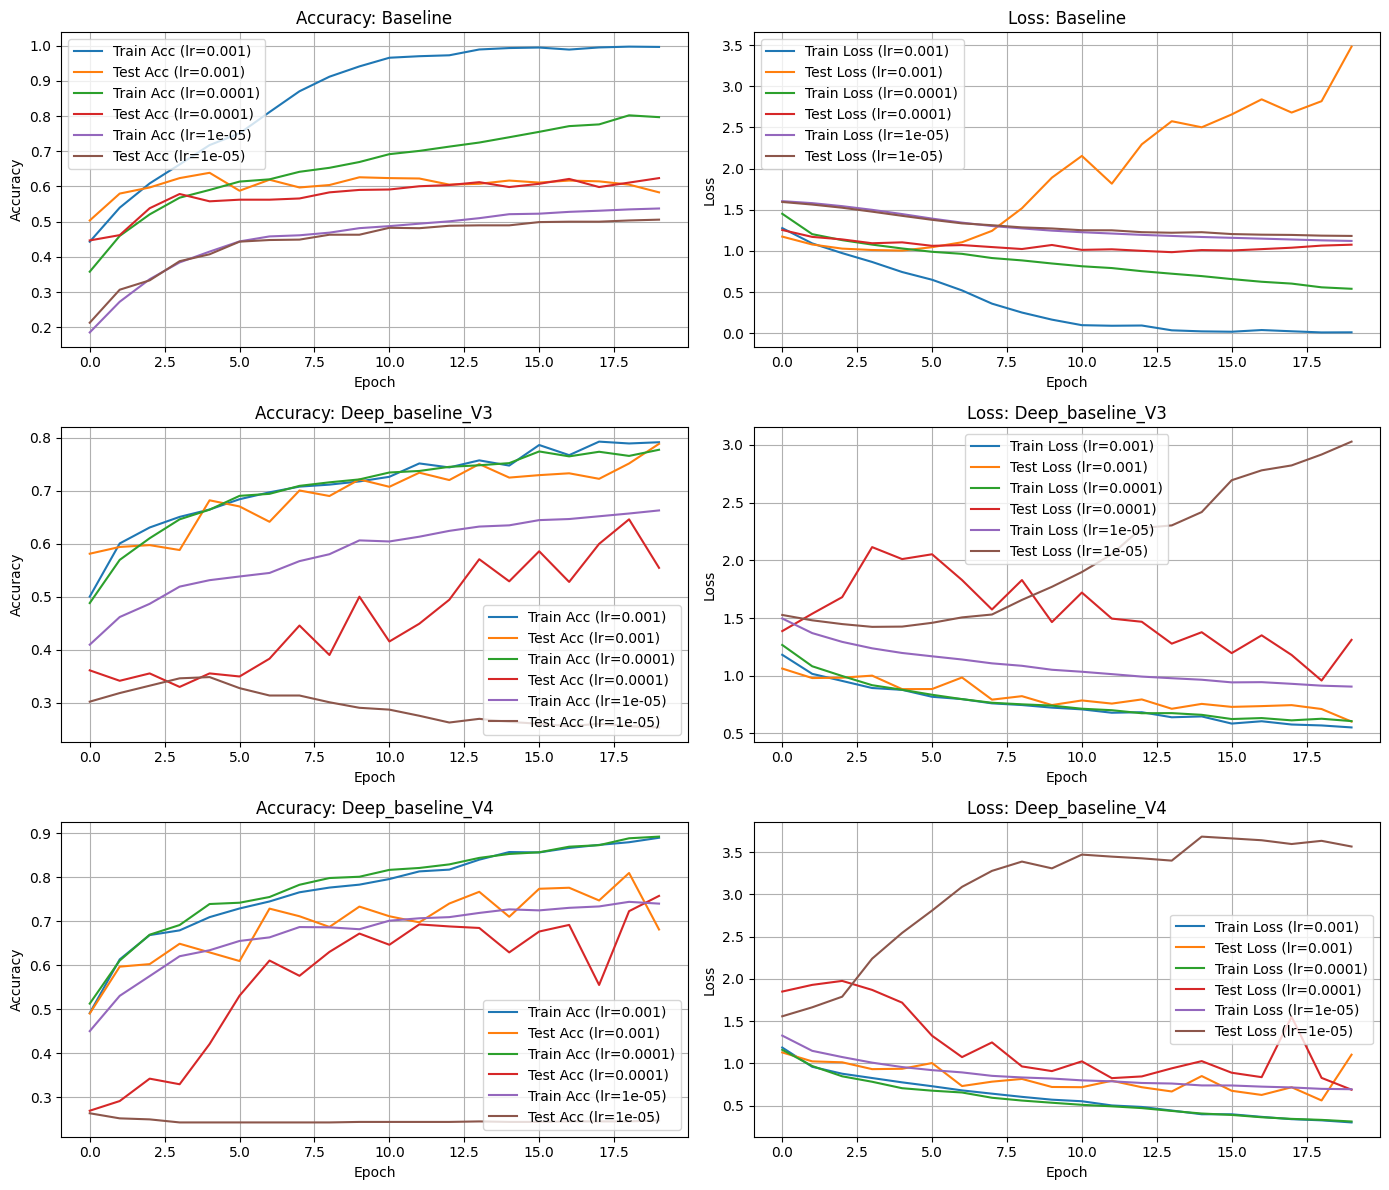

In [57]:
num_models = len(results)
fig, axes = plt.subplots(nrows=num_models, ncols=2, figsize=(14, 4 * num_models))

if num_models == 1:
    axes = np.expand_dims(axes, axis=0)  # Ensure 2D shape for single row

for idx, (model_name, result) in enumerate(results.items()):
    train_correct = result['trainCorrect']
    test_correct = result['testCorrect']
    train_losses = result['trainLosses']
    test_losses = result['testLosses']

    # Accuracy Plot
    ax_acc = axes[idx, 0]
    for lr in train_correct:
        train_acc = np.array(train_correct[lr]) / len(train_data)
        test_acc = np.array(test_correct[lr]) / len(test_data)
        ax_acc.plot(train_acc, label=f"Train Acc (lr={lr})")
        ax_acc.plot(test_acc, label=f"Test Acc (lr={lr})")

    ax_acc.set_title(f"Accuracy: {model_name}")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()
    ax_acc.grid(True)

    # Loss Plot
    ax_loss = axes[idx, 1]
    for lr in train_losses:
        ax_loss.plot(train_losses[lr], label=f"Train Loss (lr={lr})")
        ax_loss.plot(test_losses[lr], label=f"Test Loss (lr={lr})")

    ax_loss.set_title(f"Loss: {model_name}")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True)

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


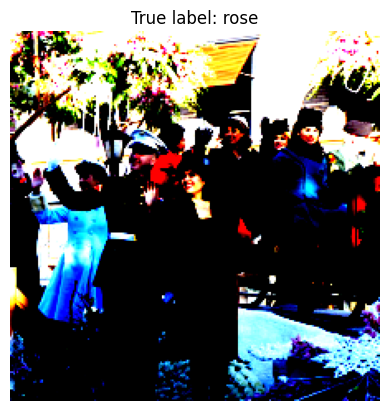

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7731092..1.7865399].


Baseline: dandelion
Deep_baseline_V3: rose
Deep_baseline_V4: tulip
--------------------------------------------------


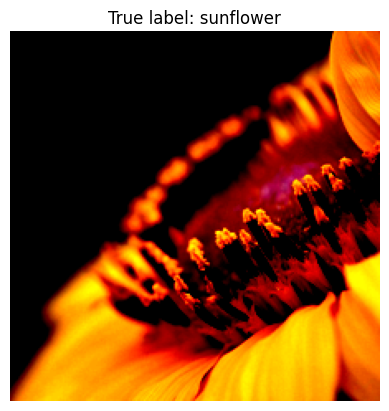

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.465708].


Baseline: dandelion
Deep_baseline_V3: rose
Deep_baseline_V4: tulip
--------------------------------------------------


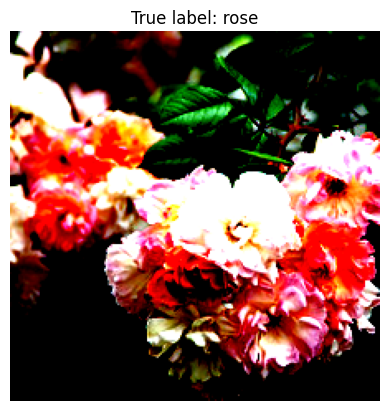

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.622571].


Baseline: dandelion
Deep_baseline_V3: rose
Deep_baseline_V4: tulip
--------------------------------------------------


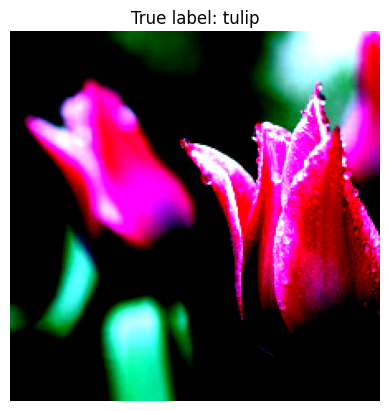

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].


Baseline: dandelion
Deep_baseline_V3: rose
Deep_baseline_V4: tulip
--------------------------------------------------


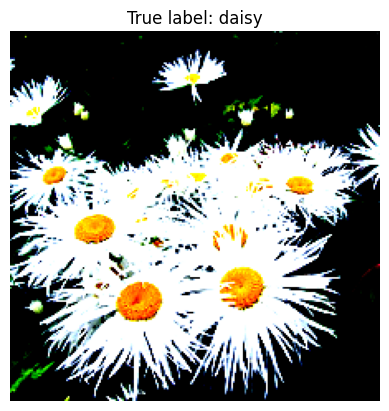

Baseline: dandelion
Deep_baseline_V3: rose
Deep_baseline_V4: tulip
--------------------------------------------------


In [ ]:
# re-initialize trained models
baseline_model = Baseline(num_classes).to(device)
v3_model = Deep_baseline_V3(num_classes).to(device)
v4_model = Deep_baseline_V4(num_classes).to(device)

# call .eval() on the instances
baseline_model.eval()
v3_model.eval()
v4_model.eval()


# Class names
class_names = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

# Pick N random samples from test data
num_samples = 5

for _ in range(num_samples):
    idx = random.randint(0, len(test_data)-1)
    image, true_label = test_data[idx]

    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"True label: {class_names[true_label]}")
    plt.axis("off")
    plt.show()

    image_input = image.unsqueeze(0).to(device)  # add batch dimension

    with torch.no_grad():
        pred_baseline = baseline_model(image_input).argmax(dim=1).item()
        pred_v3 = v3_model(image_input).argmax(dim=1).item()
        pred_v4 = v4_model(image_input).argmax(dim=1).item()

    print(f"Baseline: {class_names[pred_baseline]}")
    print(f"Deep_baseline_V3: {class_names[pred_v3]}")
    print(f"Deep_baseline_V4: {class_names[pred_v4]}")
    print("-" * 50)



In [ ]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params:,}")
    print(f"In millions: {total_params/1e6:.2f}M")

# create instances of models
baseline_model = Baseline(num_classes).to(device)
v3_model = Deep_baseline_V3(num_classes).to(device)
v4_model = Deep_baseline_V4(num_classes).to(device)

# Count parameters for each model
print("Baseline model:")
count_parameters(baseline_model)

print("\nDeep_baseline_V3 model:")
count_parameters(v3_model)

print("\nDeep_baseline_V4 model:")
count_parameters(v4_model)


Baseline model:
Total trainable parameters: 2,613,617
In millions: 2.61M

Deep_baseline_V3 model:
Total trainable parameters: 1,717,765
In millions: 1.72M

Deep_baseline_V4 model:
Total trainable parameters: 6,407,173
In millions: 6.41M


##FLOPs
In deep learning, FLOPs (Floating Point Operations) quantify the total number of arithmetic operations—such as additions, multiplications, and divisions—that a model performs during a single forward pass (i.e., when making a prediction). This metric serves as an indicator of a model’s computational complexity. When discussing large-scale models, FLOPs are often expressed in GFLOPs (Giga Floating Point Operations), where 1 GFLOP equals one billion operations. This unit helps in comparing the computational demands of different models.

In [ ]:
# we use fvcore to calculate the FLOPs
%pip install fvcore

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
from fvcore.nn import FlopCountAnalysis
input = torch.randn(1, 3, 224, 224) # The input size should be the same as the size that you put into your model
#Get the network and its FLOPs
num_classes = 5
print(models)
for model in models:
    m = model(num_classes)
    name  = model.__name__
    flops = FlopCountAnalysis(m, input)
    print(f"Model: {name} FLOPs: {flops.total()/1e9:.5f} GFLOPs")

Unsupported operator aten::max_pool2d encountered 3 time(s)
Unsupported operator aten::log_softmax encountered 1 time(s)


Unsupported operator aten::add_ encountered 4 time(s)
Unsupported operator aten::max_pool2d encountered 4 time(s)
Unsupported operator aten::log_softmax encountered 1 time(s)
Unsupported operator aten::add_ encountered 6 time(s)
Unsupported operator aten::max_pool2d encountered 6 time(s)
Unsupported operator aten::log_softmax encountered 1 time(s)


[<class '__main__.Baseline'>, <class '__main__.Deep_baseline_V3'>, <class '__main__.Deep_baseline_V4'>]
Model: Baseline FLOPs: 0.03332 GFLOPs
Model: Deep_baseline_V3 FLOPs: 2.89161 GFLOPs
Model: Deep_baseline_V4 FLOPs: 3.47013 GFLOPs


# ResNet

In [5]:
# Performing Image Transformations.

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [8]:
# Checking the flower class types.
class_names=dataset.classes
print(class_names)
print(len(class_names))

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
5


In [9]:
# Split into train/test sets
train_indices, test_indices = train_test_split(
    list(range(len(dataset.targets))),
    test_size=0.2,
    stratify=dataset.targets,
    random_state=42
)

train_data = torch.utils.data.Subset(dataset, train_indices)
test_data = torch.utils.data.Subset(dataset, test_indices)


In [10]:
#increase batch size to 32 - larger batch size means less batches, reducing training time
batch_size = 32

train_loader=DataLoader(train_data,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_data,batch_size=batch_size)

In [ ]:
# To check wether GPU has been assigned/not.
torch.cuda.is_available()
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return None
device = get_default_device()
device

device(type='cuda')

In [13]:
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [15]:
print(len(train_data))
print(len(test_data))

3453
864


In [ ]:
# Y notes: ResNet transfer learning implementation WIP
import torchvision.models as models

# load pretrained ResNet18 model
resnet = models.resnet18(pretrained=True)

# modify final layer to match 5 classes
num_classes = 5
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

# move model to device
resnet = resnet.to(device)

In [ ]:
# freeze all layers except the final fully connected layer
for param in resnet.parameters():
    param.requires_grad = False

# only train the final layer
for param in resnet.fc.parameters():
    param.requires_grad = True

# undreeze layer 3 and 4
for name, param in resnet.named_parameters():
    if 'layer3' in name:
        param.requires_grad = True

for name, param in resnet.named_parameters():
    if 'layer4' in name:
        param.requires_grad = True


In [18]:
# loss and optimizer
# criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(resnet.parameters(), lr=1e-4)

# lr scheduler
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [20]:
# Y Notes: Helper function for Torchvision Mixup feature
def mixup_data(x, y, alpha=0.4):
    '''Computer the mixup data. Return mixed inputs, pairs of targets, and lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [21]:
# Y: ResNet training loop
import time

start_time = time.time()
epochs = 20

train_losses, test_losses = [], []
train_acc, test_acc = [], []

for epoch in range(epochs):
    resnet.train()
    running_loss, correct, total = 0.0, 0, 0

    # for images, labels in train_loader:
    #     images, labels = images.to(device), labels.to(device)

    #     # Apply Mixup
    #     mixed_images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.4)

    #     outputs = resnet(mixed_images)

    #     loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)

    #     optimizer.zero_grad()
    #     loss.backward()
    #     optimizer.step()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss/len(train_loader))
    train_acc.append(correct/total)

    # Evaluation
    resnet.eval()
    test_loss, correct_test, total_test = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_losses.append(test_loss/len(test_loader))
    test_acc.append(correct_test/total_test)

    print(f"Epoch {epoch+1}/{epochs}, Train Acc: {train_acc[-1]*100:.2f}%, Test Acc: {test_acc[-1]*100:.2f}%")
    scheduler.step()

print(f"Training finished in {time.time()-start_time:.2f} seconds.")



Epoch 1/20, Train Acc: 76.77%, Test Acc: 83.45%
Epoch 2/20, Train Acc: 84.80%, Test Acc: 86.92%
Epoch 3/20, Train Acc: 87.78%, Test Acc: 89.58%
Epoch 4/20, Train Acc: 89.00%, Test Acc: 87.62%
Epoch 5/20, Train Acc: 90.56%, Test Acc: 89.93%
Epoch 6/20, Train Acc: 90.88%, Test Acc: 88.54%
Epoch 7/20, Train Acc: 91.92%, Test Acc: 89.58%
Epoch 8/20, Train Acc: 92.76%, Test Acc: 91.44%
Epoch 9/20, Train Acc: 92.47%, Test Acc: 87.96%
Epoch 10/20, Train Acc: 92.64%, Test Acc: 89.58%
Epoch 11/20, Train Acc: 93.28%, Test Acc: 92.01%
Epoch 12/20, Train Acc: 93.95%, Test Acc: 89.47%
Epoch 13/20, Train Acc: 94.24%, Test Acc: 90.39%
Epoch 14/20, Train Acc: 94.64%, Test Acc: 91.90%
Epoch 15/20, Train Acc: 94.64%, Test Acc: 91.44%
Epoch 16/20, Train Acc: 95.05%, Test Acc: 92.59%
Epoch 17/20, Train Acc: 94.61%, Test Acc: 91.44%
Epoch 18/20, Train Acc: 94.82%, Test Acc: 90.74%
Epoch 19/20, Train Acc: 95.22%, Test Acc: 91.67%
Epoch 20/20, Train Acc: 95.66%, Test Acc: 91.90%
Training finished in 631.57 s

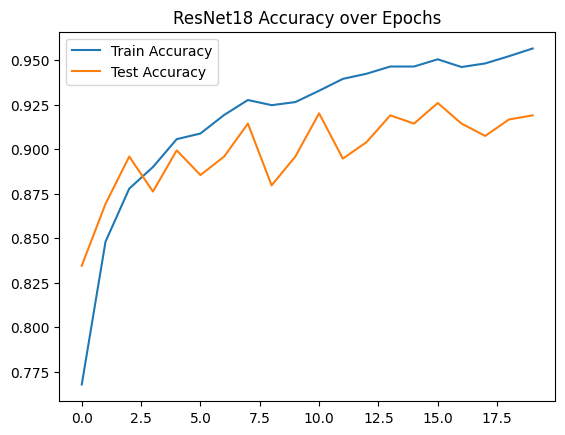

In [ ]:
# Plot accuracy
plt.plot(train_acc, label='Train Accuracy')
plt.plot(test_acc, label='Test Accuracy')
plt.title('ResNet18 Accuracy over Epochs')
plt.legend()
plt.show()

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total trainable parameters: {count_parameters(resnet):,}")

Total trainable parameters: 2,565


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.0822659].


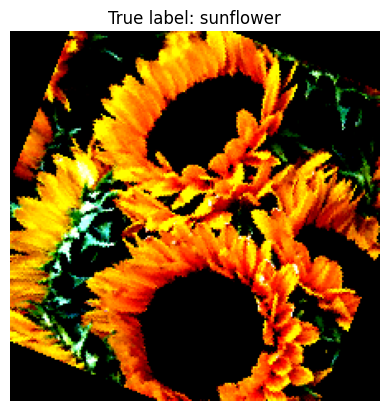

Predicted: sunflower | True: sunflower


In [45]:
# Number of random samples to test
num_samples = 1

# Make sure model is in eval mode
resnet.eval()

# Class names — adjust if needed
class_names = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

for _ in range(num_samples):
    # Randomly select an index
    idx = random.randint(0, len(test_data)-1)
    
    # Get image and label
    image, true_label = test_data[idx]
    
    # Plot image
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"True label: {class_names[true_label]}")
    plt.axis("off")
    plt.show()

    # Predict
    with torch.no_grad():
        image_input = image.unsqueeze(0).to(device)
        prediction = resnet(image_input).argmax(dim=1)
        predicted_class = class_names[prediction.item()]

    print(f"Predicted: {predicted_class} | True: {class_names[true_label]}")


In [26]:
from fvcore.nn import FlopCountAnalysis
input = torch.randn(1, 3, 224, 224).to(device) # The input size should be the same as the size that you put into your model
#Get the network and its FLOPs
num_classes = 5
model = resnet
flops = FlopCountAnalysis(model, input)
print(f"FLOPs: {flops.total()/1e9:.5f} GFLOPs")

Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)


FLOPs: 1.81856 GFLOPs
